# Modelo predictivo para ventas de E-commerce Business Transaction

*Parte 2 de estudio de caso E-commerce Business Transaction*  
**Autor:**
Javier Antonio Olvera González

## Contenido
1. [Introducción](#introducción)
2. [Metodología de optimización](#Metodolodía-de-optimización)
3. [Resultados](#resultados)
4. [Configuración del entorno](#configurando-el-entorno)
5. [Revision de tabla](#Revision-de-tabla)
6. [Ajustes en la tabla para agregarlas al modelo](#ajustes-en-la-tabla-para-agregarlas-al-modelo)
7. [**Primer modelo: RandomForestRegressor**](#primer-modelo-randomforestregressor)  
   7.1 [Evluacion del primer modelo](#evaluación-primer-modelo-randomforestregressor)
8. [**Segundo Modelo: RandomForestRegressor (Nuevos parámetros)**](#segundo-modelo-randomforestregressor-Nuevos-parámetros)  
   8.1[Evaluación del segundo modelo](#segundo-modelo)
9. [**Tercer modelo: XGBoost**](#tercer-modelo-xgboost)  
    9.1 [Evaluación tercer modelo: XGBoost](#evalución-tercer-modelo-xgboost)
10. [**Cuarto modelo: RandomForestRegeressor (Modelo B)**](#cuarto-modelo-randomforestregeressor-modelo-B)  
    10.1 [Evalucion del cuarto modelo](#evalucion-de-cuarto-modelo)
11. [**Quinto modelo: RandomForestRegressor (Modelo 0)**](#quinto-modelo-randomforestregressor-modelo-0)  
    11.1 [Evaluación quinto modelo: RandomForestRegressor (Modelo 0)](#evaluacion-quinto-modelo-randomforestregressor-modelo-0)
12. [**Sexto modelo: RandomForestRegressor (modelo 00)**](#sexto-modelo-randomforestregressor-modelo-00)  
    12.1 [**Evaluación sexto modelo: RandomForestRegressor (modelo 00)**](#sexto-modelo-randomforestregressor-modelo-00)
13. [**Séptimo modelo: RandomForestRegressor (Random_search)**](#séptimo-modelo-randomforestregressor-random_search)
14. [**Análisis de ruido del mejor modelo (Sexto modelo)**](#análisis-de-ruido-del-mejor-modelo-sexto-modelo)
15. [**Conlusión**](#conclusión)


## Introducción

Este proyecto tiene como objetivo desarrollar un modelo predictivo capaz de estimar las ventas diarias de basandose en un dataset de más de 500k entradas que cuenta con un periodo de 8 de diciembre de 2018 a 8 de diciembre de 2019. La meta es reducir la incertidumbre operativa y permitir una mejor gestión y planificación de inventarios.

Este proyecto es la continuación de [Análisis de Transacciones E-commerce: Retail UK](https://github.com/olezjavier-lgtm/Analisis_de_E-commerce), el dataset trabajado en este Notebook se extrajo de: ['E-commerce Business Transaction'](https://www.kaggle.com/datasets/gabrielramos87/an-online-shop-business/data), por [Gabriel Ramos](https://www.kaggle.com/gabrielramos87) en [Kaggle](https://www.kaggle.com/).

## Metodología de optimización

A lo largo del análisis se realizaron distintas iteraciones con la intención de encontrar un el mejor modelo y parametros que ayuden a encontrar patrones, relaciones, variables, etc. que ayuden al modelo a encontrar orden en la volatibilidad de los datos

**Modelo incial:** Se utilizo el modelo RandomForestRegressor como base

**Nuevas variables:** A lo largo del proceso de optimización se agregaron distintas variables al dataset con la intención de encontrar nuevos patrones que ayuden a mejorar el modelo

**Hiperparámetros:** Tras realizar distintas pruebas con diferentes parámetros, se optó por realizar una busqueda automática para encontrar los mejores ajustes del modelo teniendo en cuenta siempre la optimización de recursos

**Selección de modelo para últmos ajustes:** Una vez explorado las distintas posibildades en los modelos, se selecciono aquel con mejores resultados para realizar optimizaciones finales

## 3. Resultados

<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Métrica</th>
      <th style="text-align: left;">Valor</th>
      <th style="text-align: left;">Interpretación</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>Mean Absolute error (MAE)</b></td>
      <td><b>	64,965.61895</b></td>
      <td>Error promedio por día(ventas).</td>
    </tr>
    <tr>
      <td><b>Mean Squared error (MSE)</b></td>
      <td><b>91,582.0896</b></td>
      <td>Raíz del error cuadrático</td>
    </tr>
    <tr>
      <td><b>R² Score</b></td>
      <td><b>0.3032</b></td>
      <td>% de explicacion de la variabilidad</td>
    </tr>
    <tr>
      <td><b>Porcentaje de error</b></td>
      <td><b>23.59%</b></td>
      <td>MAE / promedio ventas diarias</td>
    </tr>
  </tbody>
</table>

> Resultados obtenidos del sexto modelo (modelo 00)

## Configurando el entorno

In [ ]:
%pip install seaborn pandas matplotlib
%pip install plotly

In [601]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
import xgboost as xgb
%matplotlib inline

### Descargando el dataset de Kaggle

In [602]:
import requests
import zipfile
import io

#por temas de privacidad la variable Key se cambio a una serie de *** tras haber ejecutado el análisis
user = "javierolveraaa"
key = "***************"
url = "https://www.kaggle.com/api/v1/datasets/download/gabrielramos87/an-online-shop-business"

print("Descargando dataset...")
descarga = requests.get(url, auth=(user, key))

if descarga.status_code == 200:
    z = zipfile.ZipFile(io.BytesIO(descarga.content))
    z.extractall("datos_tienda")
    print("¡Descarga y extracción exitosa!")
else:
    print(f"Error en la descarga. Código: {response.status_code}")
    print("Revisa que tus credenciales sigan siendo válidas.")

Descargando dataset...
¡Descarga y extracción exitosa!


In [603]:
data = pd.read_csv('datos_tienda/Sales Transaction v.4a.csv')

## Revision de tabla

In [604]:
data.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [605]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 22.5+ MB


>La columna 'Date' esta identificada como object, se cambiara a el formato correcto

### Cambio y verificación del formato correcto de la columna 'Date'

In [606]:
data['Date'] = pd.to_datetime(data['Date'])

In [607]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  536350 non-null  object        
 1   Date           536350 non-null  datetime64[ns]
 2   ProductNo      536350 non-null  object        
 3   ProductName    536350 non-null  object        
 4   Price          536350 non-null  float64       
 5   Quantity       536350 non-null  int64         
 6   CustomerNo     536295 non-null  float64       
 7   Country        536350 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.6+ MB


## Ajustes en la tabla para agregarlas al modelo

### Se crea una nueva columa de 'Sales' y se agrupa por la columna 'Date'

In [608]:
data['Sales'] = data['Price'] * data['Quantity']

In [609]:
# Se agrupa por por columan 'Date', las columnas 'Sales', 'Quntity' y 'TransacrionNo'
data_daily = data.groupby('Date').agg({'Sales':'sum', 'Quantity':'sum', 'TransactionNo':'nunique'}).reset_index()

In [610]:
# Se ordenan los datos en sentido ascendente por la columna 'Date'
data_daily = data_daily.sort_values('Date')

### Se crea una función para agregar columnas nuevas para el modelo

In [611]:
def create_date_times(data):
    data = data.copy()
    data['DayWeek'] = data['Date'].dt.dayofweek
    data['DayMonth'] = data['Date'].dt.day
    data['Month'] = data['Date'].dt.month
    data['Quarter'] = data['Date'].dt.quarter
    data['weekend'] = data['DayWeek'].apply(lambda x: 1 if x >= 5 else 0)
    return data

In [612]:
data_daily = create_date_times(data_daily)

### Creación de columnas que reflejan ventas pasadas según el periodo (1, 7 y 30 días)

In [614]:
data_daily['SalesLag1'] = data_daily['Sales'].shift(1)
data_daily['SalesLag7'] = data_daily['Sales'].shift(7)
data_daily['SalesLag30'] = data_daily['Sales'].shift(30) 

# se crea una columna que obtiene la media de los 7 días pasados
data_daily['RollingMean7'] = data_daily['Sales'].rolling(window=7).mean()

In [615]:
# Se eleminnan las primeras 30 filas que quedan con valores nulos
data_daily = data_daily.dropna()

## Creación del split para entrenar y probar el modelo

In [616]:
features = ['DayWeek', 'Month', 'weekend', 'SalesLag1', 'SalesLag7', 'SalesLag30', 'RollingMean7']
target = 'Sales'

split = int(len(data_daily) * 0.8)

train = data_daily.iloc[:split]
test = data_daily.iloc[split:]

x_train = train[features]
y_train = train[target]

x_test = test[features]
y_test = test[target]

## Primer modelo: RandomForestRegressor

In [617]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [618]:
y_hat = model.predict(x_test)

### Funcion para mostrar las métricas del modelo
Debido a que serán métricas que vamos a estar evaluando repetidas veces, se creo una función que llamaremos después para realizar estos cálculos de manera sencilla

In [628]:
def print_error(y_test_, y_hat_):
    mae = mean_absolute_error(y_test_, y_hat_)
    rmse = np.sqrt(mean_squared_error(y_test_, y_hat_))
    R2_score = r2_score(y_test_, y_hat_)
    # Se obtiene el promedio de las ventas de diarias del conjunto de datos destinado para el testeo
    mean_sales = float(y_test_.mean())
    pct_error = round(float(mae/mean_sales),4)*100  
    
    print(f'Mean Absolute error: {mae:.4f}')
    print(f'Mean squared error: {rmse:.4f}')
    print(f'R²: { R2_score:.4f}')
    print(f'Porcentaje de error: {round(pct_error, 2)}%')

In [625]:
# Llamando la función que acabamos de crear
print_error(y_test, y_hat)

Mean Absolute error: 66766.3541
Mean squared error: 95599.7182
R²: 0.2407
Porcentaje de error: 24.24%


>Las métricas nos muestran un error absoluto de 66,766.36 que nos indican un porcentaje de error de 24.24% tomando en cuanta la media de las ventas del conjuto de ventas que se utiliza para y_test y una R² de 0.2407, siendo estas dos métricas la que principalmente buscaremos mejorar

### Función para gráficar ventas reales vs las ventas predecidas
De igual forma que la función anterior, se creará una para graficar, debido que también se utilizará para evaular los resultados del modelo

In [622]:
def graph_error(y_hat_):
    plt.figure(figsize=(15,6))
    plt.plot(test['Date'], y_test, label='Sales', color='blue', alpha=0.5)
    plt.plot(test['Date'], y_hat_, label='Sales predicted', color='red', alpha=0.5)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title('Actual sales vs predicted sales')
    plt.legend()

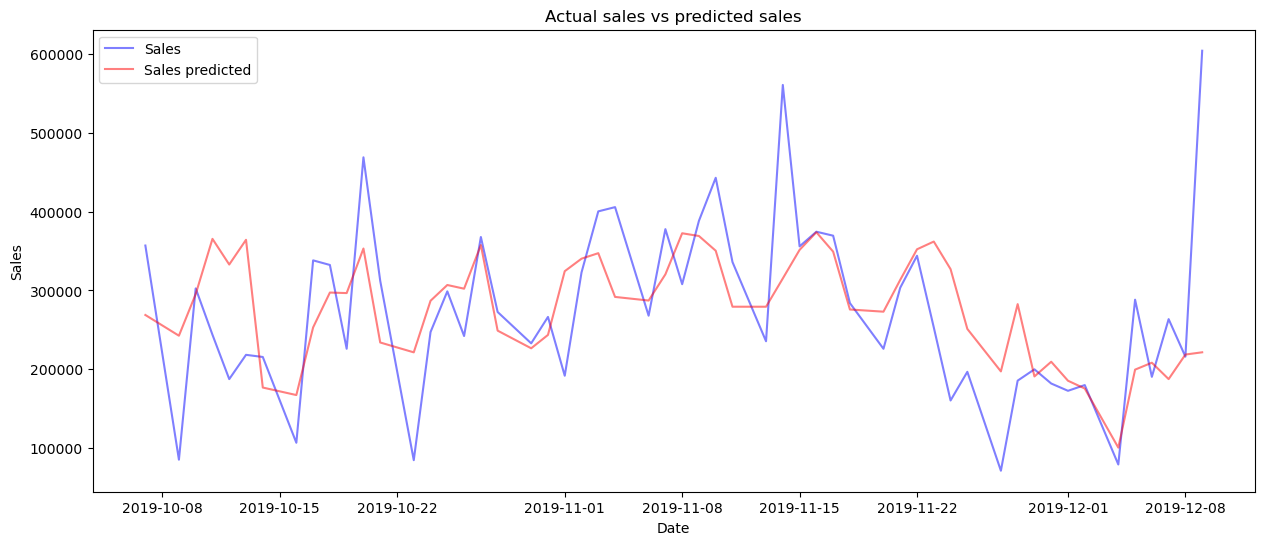

In [626]:
# Llamando a la función para graficar 'y_test vs ŷ'
graph_error(y_hat)

>La gráfica en general muestra en general seguir la tendencia de las vetnas reales, sin embargo, no es capaz de capturar de manera precisa los picos de las real de las ventas

### Función para mostrar las columnas con mayor importancia para el modelo
La función crea un gráfico de barras horizontal con la importancia en el eje x y el nombre de la columna en el eje y

In [487]:
def barh_importance(name_model, features_names, title ='Most important features'):
    importance = pd.Series(name_model.feature_importances_, index=features_names)
    importance = importance.sort_values()
    importance.plot(kind='barh', color='skyblue')
    plt.title(title)
    for i, val in enumerate(importance):
        plt.text(val +0.01, i, round(val, 4), va='center')
    plt.tight_layout()

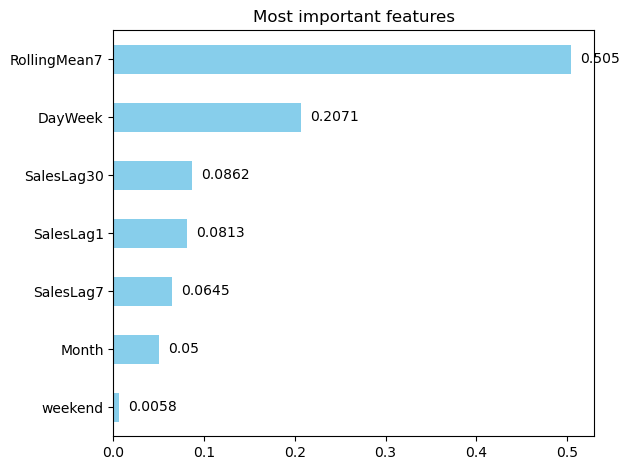

In [627]:
# Llamando a la funcion para la gráfica de barras horizontal
barh_importance(model, x_train.columns)

>Para este modelo la característica más importane fue 'RollingMean7', lo cual nos dice que fue en la que más se baso para hacer las predicciones

### Evaluación primer modelo: RandomForestRegressor

Este modelo funcionará como punto de partida para hacer ajustes en los siguientes modelos

**Parámetros utilizados**  
- no_estimators = 100  
- random_state = 42 (este se utilizará para todos los modelos)

**Métricas**  
- se obtuvo un **Mean Absolute Error (MAE)** de 66,766.36, lo cual lleva a un porcentaje de error del 24.24%  utilizando como total la media de vetnas diarias del conjunto de datos que se destino para el testeo (y_test).  
- Una **R² de 0.2407**, lo cual nos indica un aprox el 24% de las ventas se puede explicar con el modelo actual.  
- La columna 'RollingMean7' fue la que más peso tuvo en este modelo para las predicciones

**Gráfica**  
- Por otro la lado, la gráfica muestra seguir de manera general la tendencia de las ventas reales, sin emabargo en la mayoría de los puntos se quda corta pues las ventas reales muestran una gran volatilidad a lo largo de la gráfica

**Próximos pasos**
- Se seguirá utlizando el modelo RandomForestRegressor, haciendo algunos ajustes para ver si hay una mejora en la predicción de las ventas
- Debido a que se observa una gran volatilidad en las ventas, se usara una función logaritmica para que los picos más grandes no 'distraigan' al modelo y pueda caputar la mayor parte de las ventas

## Segundo Modelo: RandomForestRegressor (Nuevos parámetros)

In [630]:
#Se agregan y nuevos parametros y n_estimators cambia de 100 a 300
model_A = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=5, max_features='sqrt', random_state=42)

In [631]:
# Transformando las ventas de del conjunto de entrenamiento (y_train)
y_train_log = np.log1p(y_train)

In [632]:
model_A.fit(x_train, y_train_log)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [633]:
# Una vez entrando el modelo se hace la predicción y las ventas se regresan a su estado antes del logaritmo
y_hat_1log = model_A.predict(x_test)
y_hat_A = np.expm1(y_hat_1log)

In [634]:
print_error(y_test, y_hat_A)

Mean Absolute error: 80229.9662
Mean squared error: 106170.9541
R²: 0.0635
Porcentaje de error: 29.13%


>Comparando con los resultados del modelo anterior se un aumento en el porcentaje de error y una disminución considerable en R²

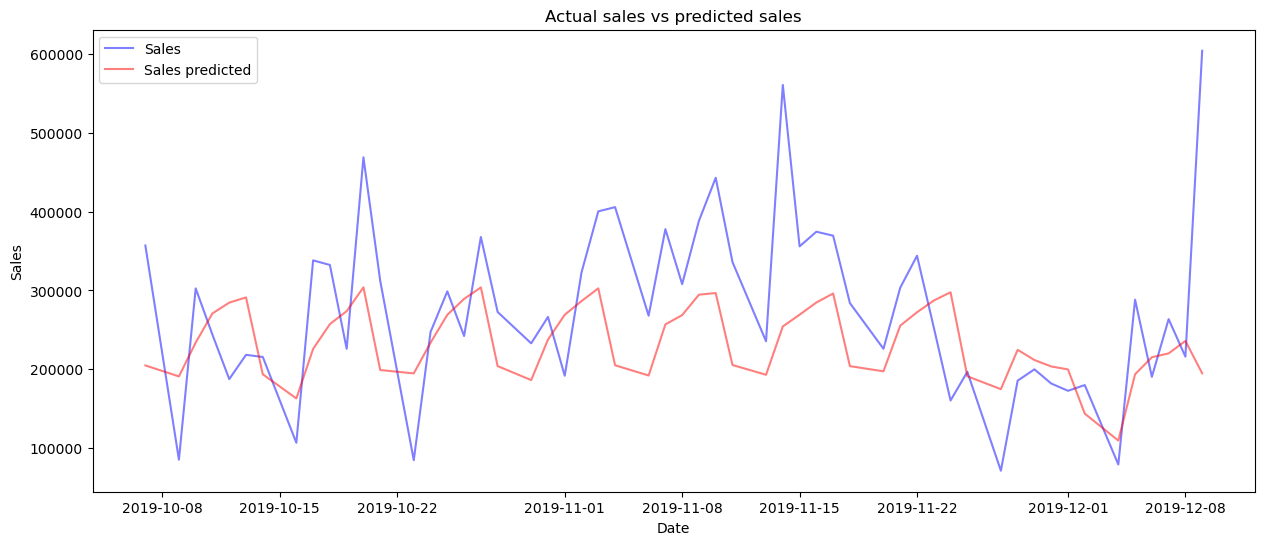

In [636]:
graph_error(y_hat_A)

>La nueva gráfica ahora ignora en su mayoría la tendencia de las ventas reales

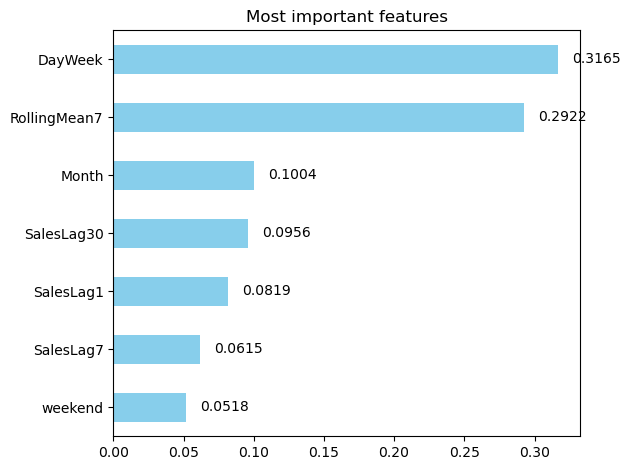

In [637]:
barh_importance(model_A, x_test.columns)

>Para este modelo, la caracteristica más importante en esta ocasión fue 'DayWeek' a diferencia del modelo anterior que era 'RollingMean7' 

### Evaluación segundo modelo: RandomForestRegressor (Nuevos parámetros)

Tras los ajustes hechos apartir del primer modelo, estos fueron los resultados:  

**Parámetros utilizados**  
- no_estimators = 300  
- max_depth = 15  
- min_samples_leaf = 5  
- max_features = 'sqrt'  
- random_state = 42 (este se utilizará para todos los modelos)

**Métricas**  
- se obtuvo un **MAE** de **80,229.9662**, significando un aumento en el porcentaje de error a un **29.13%**, llevando a inferir que los resultados del primero modelo superan a los actuales.  
- Con una **R² de  0.0635**, se muestra una claro detereoro teniendo una **R²  de 0.2407** en el modelo anterior.
- Para este modelo, la columna 'Dayweek' fue la primera en la gráfica de barras, pero, de igual forma se puede observar que 'RollingMean7' tuvo una importancia muy similar.

**Gráfica**  
- La gráfica mostro un peor rendimiento en la predicción de las ventas, al no mostrar un seguimiento de la tendencia de las ventas reales

**Próximos pasos**
- Se buscarán valores atípico, para ver si se encuentran tendencias en algunos días en específico para darles nuevas señales al modelo
- Al ver que las características (columnas) que actualmente esta usando el modelo podrían estarse quedando cortas para mejorar la predicción se agregará una nueva columna apartir del promedio de ventas por día del mes (1 al 31) para encontrar patrones que el modelo pueda identificar según el día del mes

#### Busacando patronres

In [184]:
data_daily = data_daily.reset_index(drop=True)

In [157]:
data_daily['Sales'].max()

np.float64(604502.11)

In [158]:
filter_sales = data_daily[data_daily['Sales']==604502.11]
filter_sales

,index,Date,Sales,Quantity,TransactionNo,DayWeek,DayMonth,Month,Quarter,weekend,SalesLag1,SalesLag7,SalesLag30,RollingMean7
274,304,2019-12-09,604502.11,12901,48,0,9,12,4,0,215952.78,172592.36,405865.65,260226.608571


#### Obteniendo la media de ventas e los días 15 y 30 del mes

In [169]:
filter_q = data_daily[data_daily['DayMonth'].isin([15,30])]
filter_q['Sales'].mean()

np.float64(198029.41875)

#### Agrupando la ventas por día del mes

In [176]:
filter_day = data_daily.groupby('DayMonth')['Sales'].mean().reset_index()
filter_day.sort_values('Sales', ascending=False, inplace=True)

In [179]:
filter_day

,DayMonth,Sales
4,5,249989.262500
8,9,240203.051111
19,20,234040.196000
10,11,228127.102222
21,22,222786.353750
16,17,220040.478000
3,4,217626.311000
18,19,217197.585000
13,14,213522.156667
17,18,209534.382000


>En promedio  los días con mayor promedio de ventas son los 5, 9 y 20 de cada mes, por otro lados, los días 27, 1 y 26 se muestran como los días con ventas más bajas

##### Gráfica de las ventas promoedio por día del mes

<Axes: xlabel='DayMonth', ylabel='Sales'>

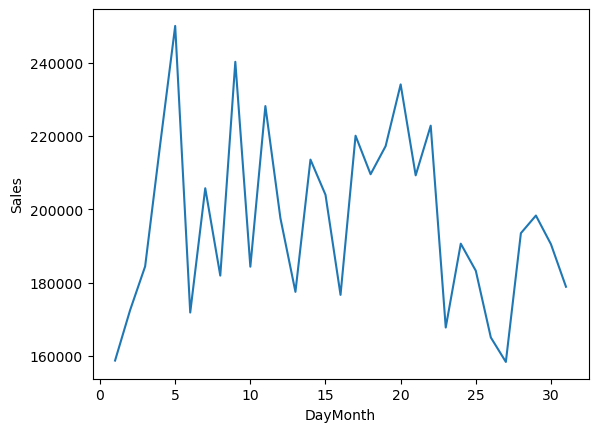

In [182]:
filter_day_line = filter_day.sort_values('DayMonth')
sns.lineplot(filter_day_line, x='DayMonth', y='Sales')

In [639]:
data_daily.describe()

,Date,Sales,Quantity,TransactionNo,DayWeek,DayMonth,Month,Quarter,weekend,SalesLag1,SalesLag7,SalesLag30,RollingMean7
count,275,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000
mean,2019-06-29 12:44:30.545454592,196920.532764,17518.123636,75.534545,3.367273,15.574545,6.450909,2.483636,0.341818,195714.065382,195061.709745,188587.362691,195482.640826
min,2019-01-16 00:00:00,22892.130000,2048.000000,11.000000,0.000000,1.000000,1.000000,1.000000,0.000000,22892.130000,22892.130000,22892.130000,90294.735714
25%,2019-04-05 12:00:00,130902.165000,11624.500000,58.000000,2.000000,8.000000,4.000000,2.000000,0.000000,130902.165000,129320.875000,126629.745000,153263.749286
50%,2019-07-01 00:00:00,180572.300000,15650.000000,71.000000,4.000000,16.000000,7.000000,3.000000,0.000000,180572.300000,178061.300000,175661.100000,180671.967143
75%,2019-09-20 12:00:00,241115.685000,21365.000000,91.000000,5.000000,23.000000,9.000000,3.000000,1.000000,241115.685000,239224.795000,232985.875000,222055.097143
max,2019-12-09 00:00:00,604502.110000,47125.000000,182.000000,6.000000,31.000000,12.000000,4.000000,1.000000,561052.510000,561052.510000,548012.490000,384989.324286
std,NaN,99408.130229,8946.920867,29.050951,1.977894,8.781039,3.166941,1.078449,0.475184,96411.613797,96779.417474,90914.421717,60766.848115


>En la tabla podemos ver el promedio de ventas diarias en general, al mismo tiempo podemos ver una desviación estandar de $99,408.13 lo cual representa que los datos están muy dispersos de la media, esto nos lleva a confirmar la volatilidad

### Agregando los promedios de ventas por día del mes  ala tabla

In [642]:
# Creando un diccionario con la tabla para poder mapear los datos a la tabla principal (data_daily)
peak_days = data_daily.groupby(data_daily['Date'].dt.day)['Sales'].mean().to_dict()

# Llamaremos a la nueva columna 'DayStrength'
data_daily['DayStrength'] = data_daily['Date'].dt.day.map(peak_days)


In [641]:
data_daily.head()

,Date,Sales,Quantity,TransactionNo,DayWeek,DayMonth,Month,Quarter,weekend,SalesLag1,SalesLag7,SalesLag30,RollingMean7,DayStrength
30,2019-01-16,48153.66,4177,29,2,16,1,1,0,272723.58,183219.61,324649.23,167906.282857,176626.940
31,2019-01-17,164209.64,13360,53,3,17,1,1,0,48153.66,96653.70,260301.65,177557.131429,220040.478
32,2019-01-18,104281.74,8705,48,4,18,1,1,0,164209.64,154106.61,201975.18,170439.292857,209534.382
33,2019-01-19,196727.48,17252,40,5,19,1,1,1,104281.74,354429.31,196630.80,147910.460000,217197.585
34,2019-01-20,123728.70,10343,47,6,20,1,1,1,196727.48,130984.64,270656.87,146873.897143,234040.196


### Actualizando el split de entrenamiento y testeo para los siguientes modelos

In [643]:
# Agregamos la nueva columna  a nuestra lista de caracteristicas para el modelo, en una nueva variable para no afectar los resultados de los modelos anteriores
features_A = ['DayWeek', 'Month', 'weekend', 'SalesLag1', 'SalesLag7', 'SalesLag30', 'RollingMean7','DayStrength' ]

In [644]:
# Se crean nuevas variables de prueba y testeo para las nuevas caracteristicas
train = data_daily.iloc[:split]
test = data_daily.iloc[split:]

x_train_A = train[features_A]
y_train_A = train[target]

x_test_A = test[features_A]
y_test_A = test[target]

## Tercer modelo: XGBoost

In [645]:
model_xgb = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, random_state=42)

In [647]:
# Se vuelve a utlizar la variable logaritmica para las ventas
model_xgb.fit(x_train_A, y_train_log)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [648]:
y_hat_xgb = np.expm1(model_xgb.predict(x_test_A))

In [649]:
print_error(y_test_A, y_hat_xgb)

Mean Absolute error: 75581.3216
Mean squared error: 103097.2907
R²: 0.1170
Porcentaje de error: 27.44%


>Se obtiene un ligera mejora en el tecer modelo en comparación con el segundo modelo, sin embargo, el primero modelo presenta mejores resultados

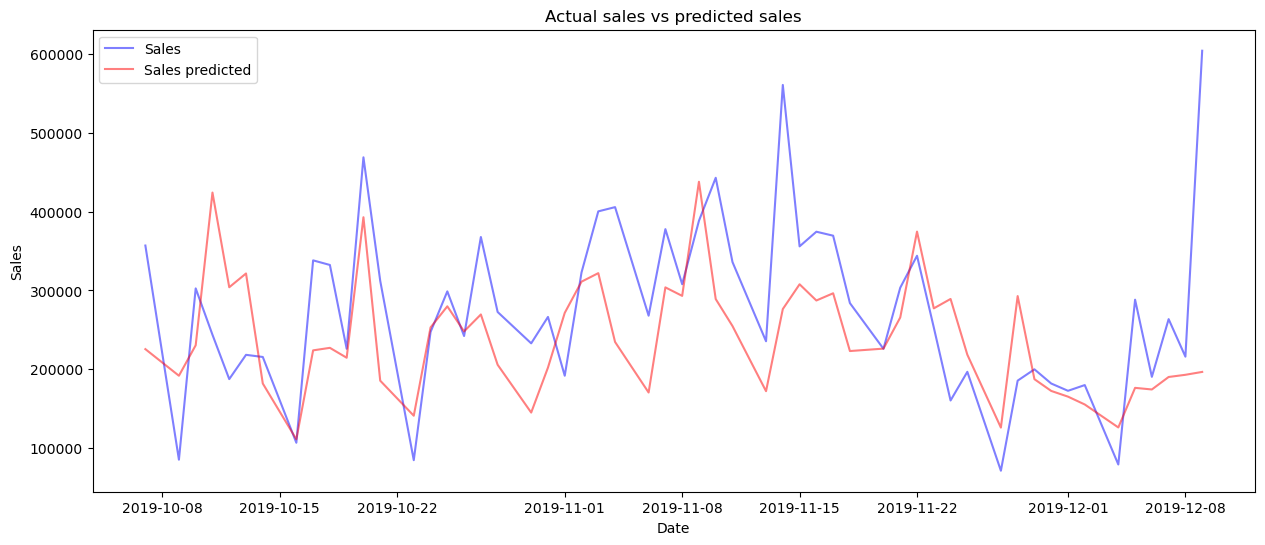

In [650]:
graph_error(y_hat_xgb)

>Se puede observar que la gráfica captura de mejor manera algunos picos en las ventas reales 

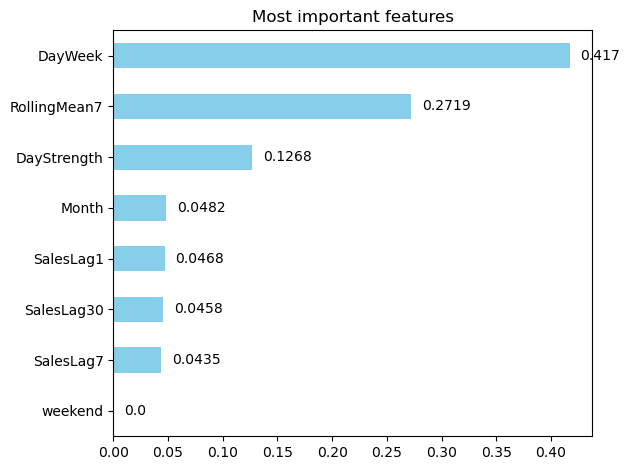

In [651]:
barh_importance(model_xgb, x_test_A.columns)

>Para este modelo, 'DayWeek' volio a aparecer en el primer puesto, al mismo tiempo 'DayStrength' en la lista, ambas se encuentran relacionadas

### Evaluación tercer modelo modelo: XGBoost

Despues de utilizar un nuevo modelo (XGBoost) estos fueron los resultados:

**Parámetros utilizados**  
- no_estimators = 500
- learning_rate = 0.05 
- max_depth = 6
- subsample = 0.8  
- min_samples_leaf = 5  
- random_state = 42 (este se utilizará para todos los modelos)

**Métricas**  
- se obtuvo un **MAE** de **75,581.3216**, representando un porcentaje de erorr de 27.44%. Una ligera mejora en comparación del modelo anterior, sin embargo, peor que el primer modelo
- Con una **R² de  0.1170**, de igual forma, una mejora que el modelo anterior, pero lejos del primero modelo
- Para este modelo, la columna 'Dayweek' fue la primera en la gráfica de barras, apareciendo junto con 'DayStrength'
**Gráfica**  
- La gráfica muestra seguir de mejor forma las altas y bajas de las ventas, al mismo tiempo captura parte de la tendencia general

**Próximos pasos**
- Se volverá a utilizar el modelo RadomForestRegressor, con la intención de mejorar los resultados del primer modelo

## Cuarto modelo: RandomForestRegeressor (Modelo B)

In [652]:
model_B = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_split=2, max_features='log2', random_state=42)

In [670]:
model_B.fit(x_train_A, y_train_log)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [654]:
y_hat_B = np.expm1(model_B.predict(x_test_A))

In [655]:
print_error(y_test_A, y_hat_B)

Mean Absolute error: 74356.4756
Mean squared error: 100549.0474
R²: 0.1601
Porcentaje de error: 27.0%


>Ligera mejora comparando con el tercer modelo pero no supera al primero modelo

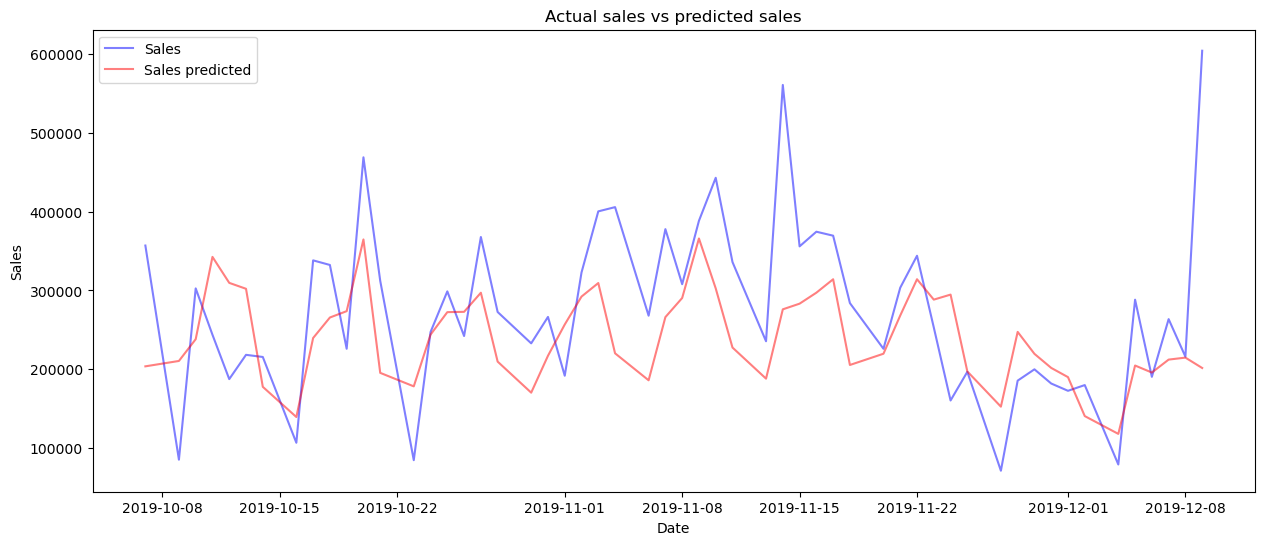

In [656]:
graph_error(y_hat_B)

> El cuarto modelo, no predice tan bien los picos y bajas de las ventas diarias

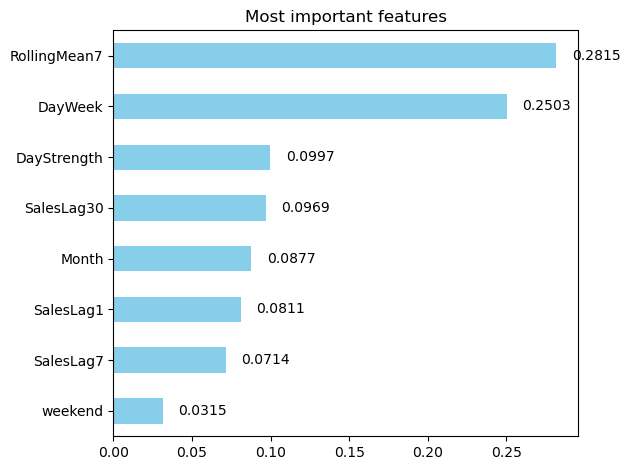

In [657]:
barh_importance(model_B, x_test_A.columns)

> Este modelo muestra un distribucion de mas uniforme en comparación con los demás modelos

### Evaluación cuarto modelo: RandomForestRegressor (Modelo B)

Despues de utilizar un nuevo modelo (XGBoost) estos fueron los resultados:

**Parámetros utilizados**  
- no_estimators = 500
- max_depth = None
- min_sample_split= 2
- max_features = 'log2'
- random_state = 42 (este se utilizará para todos los modelos)

**Métricas**  
- se obtuvo un **MAE** de **74,356.4756**, representando un porcentaje de erorr de 27.0%. Nuevamente mostrando una ligera mejora comparado al modelo anterior  
- Con una **R² de  0.1601**, siendo más bajo que en el primer modelo
- 'RollingMean7' fue la columna con mayor importancia, además se puede observar otras variables que tomaron más peso
**Gráfica**  
- La gráfica se muestra más conservadora esta vez, ya no busca capturar los picos y puntos bajo de las ventas, parace buscar más la media

**Próximos pasos**
- Tomando en cuentaque el primero modelo tuvo mejores resultados de todos los que se han probado hasta el momento, se volverá a utilizar los mismo parámetros, pero ahora utilizando la tabla con la nueva columna 'Daystrength' para confirmar si esta puede ayudar al modelo a mejorar los resultados
- Al mismo tiempo, se volverá a usar el conjunto de entrenamiento sin logaritmo

## Quinto modelo: RandomForestRegressor (Modelo 0)

In [658]:
model_0 = RandomForestRegressor(n_estimators=100, random_state=42)

In [659]:
model_0.fit(x_train_A, y_train_A)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [661]:
y_hat_0 = model_0.predict(x_test_A)

In [662]:
print_error(y_test_A, y_hat_0)

Mean Absolute error: 67947.6218
Mean squared error: 94369.8760
R²: 0.2601
Porcentaje de error: 24.67%


> El modelo muestra una clara mejora en especial en R² con un 0.2601 en comparacion del 0.2407 del primer modelo, por otro lado, el porcentaje de error sigue arriba con un 24.67% en compracion con un 24.24% del primero modelo

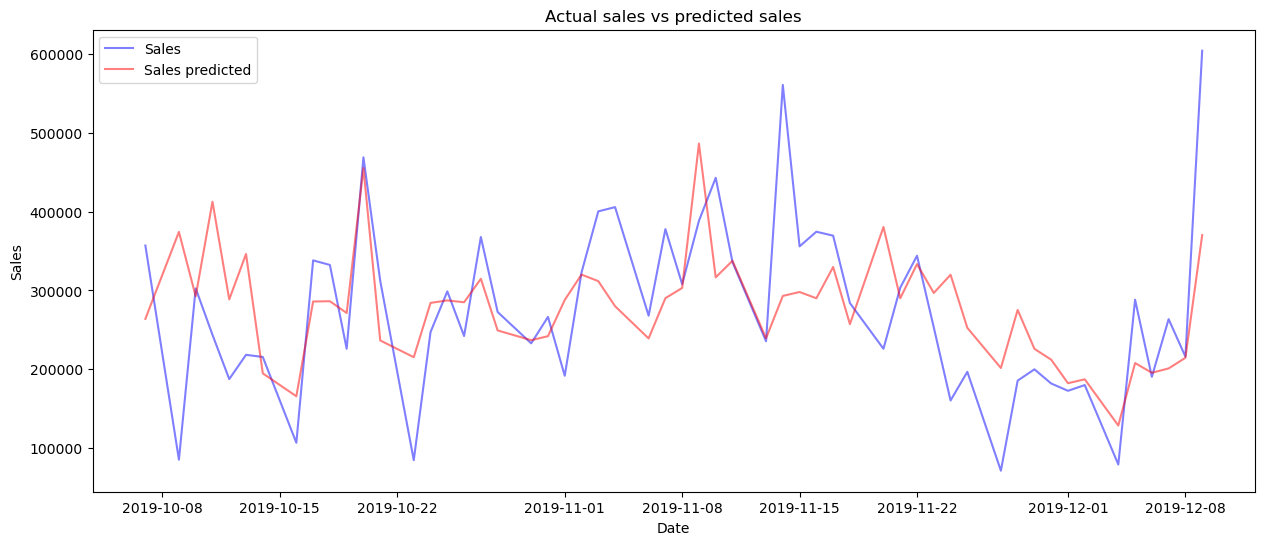

In [663]:
graph_error(y_hat_0)

> La grafica muestra una mayor flexibilidad para los picos que muestran las ventas, sin embargo, al principio, del lado izquierdo muestra un resultado totalmente opuesto

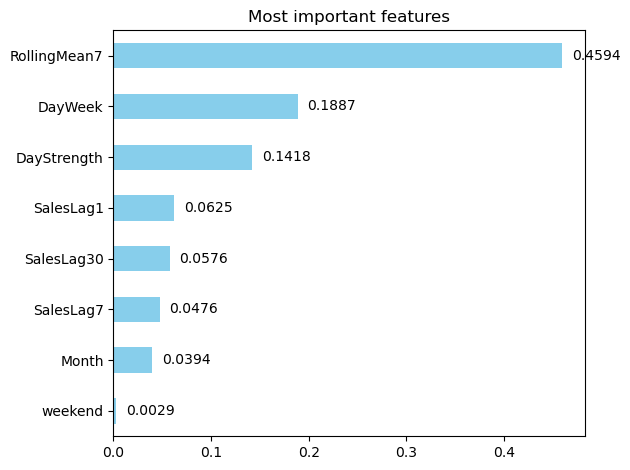

In [664]:
barh_importance(model_0, x_train_A.columns)

> Nuevamente 'RollingMean7' cuanta con mayor peso para el modelo

### Evaluación del quinto modelo (modelo 0)

Despues de utilizar el primer modelo (RandomForestRegressor) con una nueva columna ('DayStrength')estos fueron los resultados:

**Parámetros utilizados**  
- no_estimators = 100
- random_state = 42 (este se utilizará para todos los modelos)

**Métricas**  
- se obtuvo un **MAE** de **67,947.6218**, con una disminución del porcentaje de error a 24.67%
- Con una **R² de  0.2601**, mostrando un mejor resultado que el primero modelo que contaba con un 0.2407
- 'RollingMean7' volvio a tener mayor peso en comparación para las demas variables
**Gráfica**  
- La gráfica muestra un mejor comportamiento en los picos y puntos bajos, sin embargo, al inicio de la gráfica las ventas esperadas muestran estar muy lejos de las ventas reales

**Próximos pasos**
- Continuando con esta línea donde se agrego la columna 'DayStrength' al primer modelo, se configurará el parámetro 'min_samples_leaf' a 3 para evitar un sobre ajuste

## Sexto modelo: RandomForestRegressor (modelo 00)

In [665]:
model_00 = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_leaf=3)


In [666]:
model_00.fit(x_train_A, y_train_A)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [667]:
y_hat_00 =model_00.predict(x_test_A)

In [668]:
print_error(y_test_A, y_hat_00)

Mean Absolute error: 64965.6189
Mean squared error: 91582.0896
R²: 0.3032
Porcentaje de error: 23.59%


>Nuevamente se obtuvo un mejor resultado en R² y en el porcentaje de error, mostrando una clara mejora en el modelo

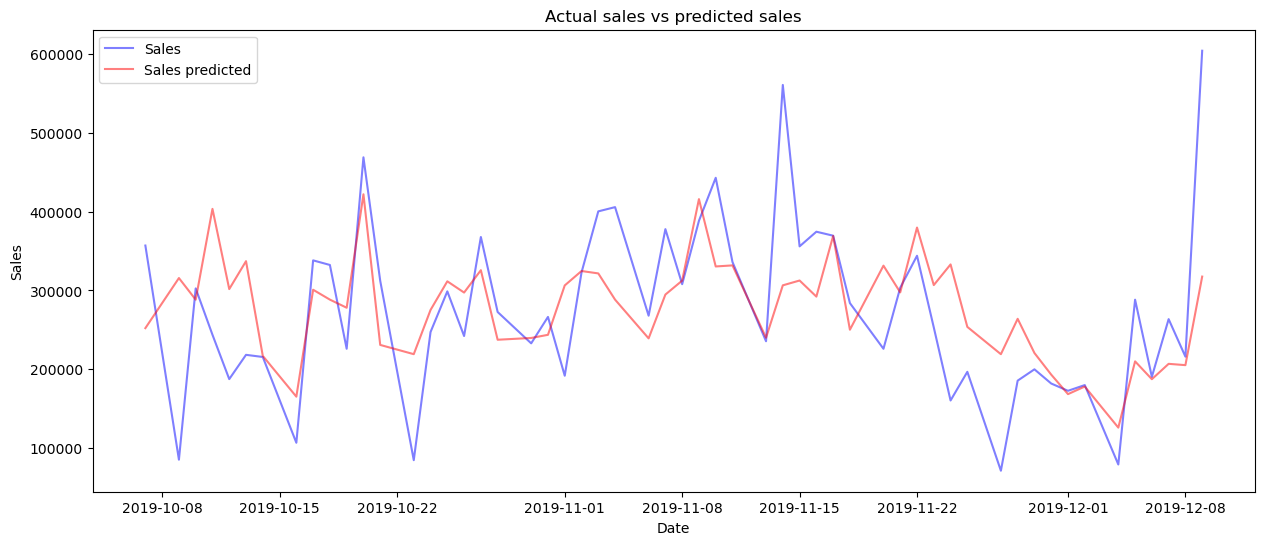

In [535]:
graph_error(y_hat_00)

> la gráfica muetra capturar parte de la tendencia general de las ventas, aún así, al principio de la grafica muestra tener problema con la prediccion

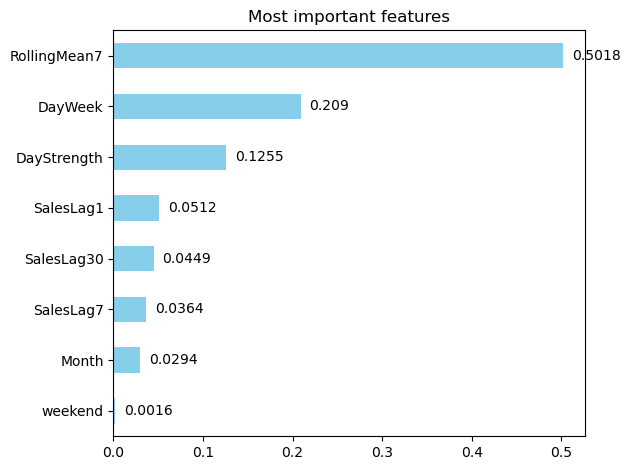

In [669]:
barh_importance(model_00, x_train_A.columns)

> El nivel jerárquico parece mantenerse igual, al menos en los primero tres, lo cual nos deja en claro, que el ajuste de 'min_sample_leaf' realmente influyo en los resultados

## Evaluación del sexto modelo (modelo 00)

Tras ajustar el quinto modelo con el parámetro 'min_samples_leaf', los resultado obtenidos son:

**Parámetros utilizados**  
- no_estimators = 100
- min_samples_leaf = 3
- random_state = 42 (este se utilizará para todos los modelos)

**Métricas**  
- se obtuvo un **MAE** de **64,965.6189**, con una disminución del porcentaje de error a 23.59% logrando ser más bajo que el del primero modelo (24.24%)
- Con una **R² de  0.3032**, siendo el modelo con el valor más alto en esta métrica
- Se mantuvieron las mismas tres columnas en el nivel de importancia de la gráfica de barras horizontal
**Gráfica**  
- La gráfica sigue mejor la tendencia de las ventas, sobre todo en los picos

**Próximos pasos**
- Se realizará un RandomizedSearchCv utlizando el modelo RandomForestRegressor, ajustando principalmente el parámetro 'min_samples_leaf' entre 3 y 4

## Séptimo modelo: RandomForestRegressor (Random_search)

Dado a que nuestro conjunto de datos es una serie de tiempo, usaremos 'TimeSeriesSplit' para no afectar el modelo utilizando una cross validation

In [545]:
tscv = TimeSeriesSplit(n_splits=5)

In [546]:
model_00 = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_leaf=3)

In [585]:
# Definiendo los parámtreos para RandomizedSearchCV
param_dist = {'n_estimators': [100, 300, 500], 'max_depth': [None, 10, 20, 30], 'min_samples_leaf': [3, 4], 'min_samples_split': [2, 5, 10],  'max_features': ['sqrt', 'log2', None]}

In [586]:
random_search = RandomizedSearchCV(estimator=model_0, param_distributions=param_dist, n_iter=15, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42, verbose=1)

In [587]:
random_search.fit(x_train_A, y_train_A)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [3, 4], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,15
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [588]:
# Obteniendo los mejores parámetros para poner a prueba el modelo
best_model = random_search.best_estimator_

In [589]:
print(best_model)

RandomForestRegressor(max_depth=10, max_features='log2', min_samples_leaf=3,
                      n_estimators=300, random_state=42)


In [590]:
best_model

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [591]:
y_hat_best_model = best_model.predict(x_test_A)

In [592]:
print_error(y_test_A, y_hat_best_model)

Mean Absolute error: 68096.0416
Mean squared error: 93939.5209
R²: 0.2669
Porcentaje de error: 24.73%


> R² muestra una mejora en comparación con el primer modelo, sin embargo, muestra ser más bajo que el Sexto modelo (0.3032)

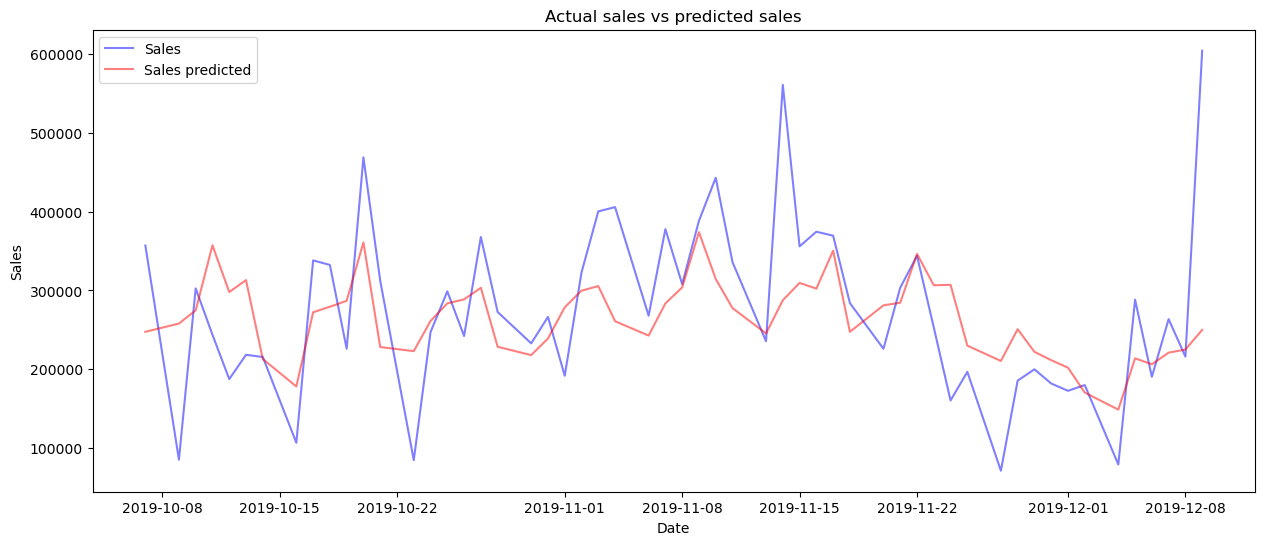

In [675]:
graph_error(y_hat_best_model)

>La gráfica se muestra más cautelosa en la tendencia de los picos

In [595]:
resid = y_test_A - y_hat_00

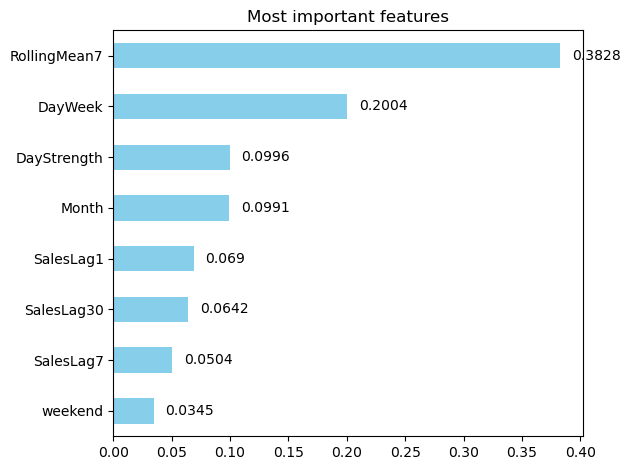

In [678]:
barh_importance(best_model, x_train_A.columns)

## Análisis de ruido del mejor modelo (Sexto modelo)

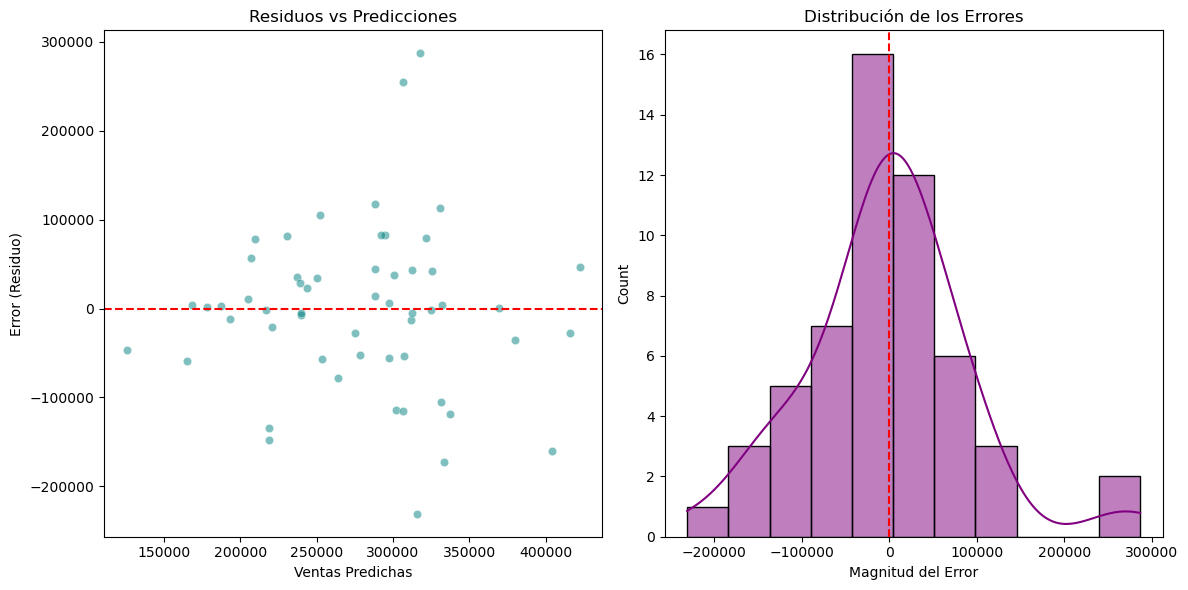

In [679]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_00, y=resid, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs Predicciones')
plt.xlabel('Ventas Predichas')
plt.ylabel('Error (Residuo)')


plt.subplot(1, 2, 2)
sns.histplot(resid, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribución de los Errores')
plt.xlabel('Magnitud del Error')

plt.tight_layout()
plt.show()

**Gráfico de residuos**  
En el gráfico de residuos (gráfico de la izquierda) podemos ver que no econtramos un patros claro en los datos, si bien encontramos que hacia la derecha se ven más dispersos lo cual representa que al modelo le cuesta más predcir los puntos bajos y altos relacionado con la disperción estandar de la media de las ventas diarias

**Histograma**  
Se puede observar que las barrar principalmente se centran alrededor del cero, como en una distribución normal

## Conclusión

Dado a que las ventas presentan un volatilidad bastenta alta, se vuelve dificil para el modelo presentar una mejor predicción, al mismo timpo podemos ver una desviación estandar de la media de las ventas de 99,408.130 siendo la media de 196,920.53, lo cual representa una desviación estandar aproximamente del 50% del tamaño del promedio.  

Ahora bien, el modelo podría presentar mejorar nuevas columnas que retroalimenten de mejor manera al modelo, que ayuden a explicar mejor el por qué de la volatilidad de las ventas como ciertas carácteristicas, como el perfil del cliente, en caso que tengan distribuidores recurrentes mes con mes.  

Por otra parte, el modelo presento un mejor desempeño con configuraciones más simples, aún cuando se utilizo un randomsearch tomando como base el mejor modelo  

El modelo podría utilizarse como referencia para el negocio para conocer que podría esperar en el día a día de las ventas y siendo retroalimentado

### Autor:  
**Javier Antonio Olvera González**  
Análista de datos